<img src="https://upload.wikimedia.org/wikipedia/commons/3/35/Uba_fiuba_ingenieria_logo.png" width="300" align="center">



# **Analisis de Series de Tiempo II**

# **Clase 7, Del punto a la Distribución**

Dataset: demanda diaria de bicicletas (Capital Bikeshare, 2011–2012).

---

Instalamos lo necesario

In [ ]:
!pip install -q "chronos-forecasting>=2.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.6/80.6 kB 7.5 MB/s eta 0:00:00


In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.stats import norm
plt.rcParams["figure.figsize"] = (11, 3.6)

URL = ("https://raw.githubusercontent.com/udacity/deep-learning-v2-pytorch/"
       "master/project-bikesharing/Bike-Sharing-Dataset/day.csv")

Cargamos el dataset de bicicletas de Washington DC (2011-2012). Definimos un horizonte de 7 días y los 9 niveles de cuantiles (0.1 a 0.9).

In [ ]:
s = (pd.read_csv(URL, parse_dates=["dteday"])
       .rename(columns={"dteday": "ds", "cnt": "y"})[["ds", "y"]]
       .sort_values("ds").reset_index(drop=True))

H  = 7
QL = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
QC = [str(q) for q in QL]
print(len(s), "días |", s.ds.min().date(), "->", s.ds.max().date())

731 días | 2011-01-01 -> 2012-12-31


**Antes: un número, ahora es un abanico.**

---

* Tomamos las últimas 56 observaciones (8 semanas), les asignamos el día de la semana (dow: lunes=0, martes=1, etc.), y calculamos el promedio histórico de demanda para cada día de la semana.

* Después, para los 7 días que hay que pronosticar, simplemente les asignamos el promedio histórico correspondiente a su día de semana (ej. "los martes en promedio se alquilan 4300 bicis, así que predigo 4300 para este martes").

In [ ]:
d = s.iloc[:-H].copy(); d["dow"] = d.ds.dt.dayofweek
promedio_por_dia = d.tail(56).groupby("dow").y.mean()
fechas = s.ds[-H:]
punto = np.array([promedio_por_dia[f.dayofweek] for f in fechas])

print("Pronóstico puntual:", punto.round(0))

Pronóstico puntual: [4767. 5352. 4941. 5170. 4644. 4063. 4878.]


En Chronos, en vez de un número por día, hay nueve.

In [ ]:
from chronos import Chronos2Pipeline
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
pipe = Chronos2Pipeline.from_pretrained("amazon/chronos-2", device_map=device)

df = s.rename(columns={"ds": "timestamp", "y": "target"}).assign(item_id="bicis")
pred = pipe.predict_df(df.iloc[:-H], prediction_length=H, quantile_levels=QL,
                       id_column="item_id", timestamp_column="timestamp", target="target")
pred["timestamp"] = pd.to_datetime(pred["timestamp"])

pred[["timestamp"] + QC].round(0)

config.json:   0%|          | 0.00/1.07k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  478MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

,timestamp,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9
0,2012-12-25,291.0,956.0,1396.0,1728.0,2035.0,2348.0,2696.0,3118.0,3692.0
1,2012-12-26,1161.0,1943.0,2486.0,2943.0,3344.0,3727.0,4097.0,4522.0,5074.0
2,2012-12-27,1543.0,2409.0,2991.0,3461.0,3870.0,4255.0,4620.0,5025.0,5536.0
3,2012-12-28,1776.0,2638.0,3202.0,3665.0,4075.0,4453.0,4801.0,5176.0,5651.0
4,2012-12-29,1756.0,2630.0,3205.0,3664.0,4067.0,4440.0,4785.0,5160.0,5635.0
5,2012-12-30,1714.0,2590.0,3164.0,3625.0,4025.0,4396.0,4741.0,5124.0,5597.0
6,2012-12-31,1770.0,2674.0,3264.0,3725.0,4119.0,4477.0,4806.0,5168.0,5621.0


* La mediana (0.5) es el pronóstico puntual de antes. Es decir, no se perdió nada al pasar al modelo probabilístico.
* El número que daba el modelo antiguo sigue estando ahí, es simplemente el cuantil 0.5.
* Lo que se ganó es todo lo demás: los otros 8 números que antes "se descartaban" y que ahora te dicen cuán ancho o angosto es el rango de incertidumbre alrededor de ese número central.

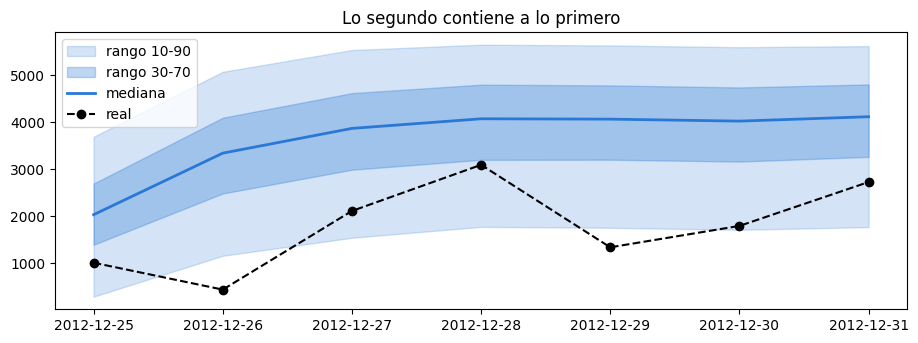

In [ ]:
real = s.tail(H)
x = pred.timestamp.values

plt.fill_between(x, pred["0.1"], pred["0.9"], color="#2a78d6", alpha=.20, label="rango 10-90")
plt.fill_between(x, pred["0.3"], pred["0.7"], color="#2a78d6", alpha=.30, label="rango 30-70")
plt.plot(x, pred["0.5"], color="#2a78d6", lw=2, label="mediana")
plt.plot(real.ds.values, real.y.values, "ko--", label="real")
plt.legend(); plt.title("Lo segundo contiene a lo primero");

**Las tres formas de entregar el abanico**


Este bloque muestra que "ser probabilístico" no es una sola técnica, sino que hay tres formas distintas de representar la misma incertidumbre, y compara cómo se ven.

**Paramétrica**

* Calcula los residuos (diferencia entre el valor real y la predicción del promedio por día de semana) sobre las últimas 8 semanas, y toma su desviación estándar (sigma).
* La idea es: en vez de dar 9 números, describimos toda la distribución con solo dos parámetros: una media y un desvío estándar, asumiendo que la incertidumbre tiene forma de campana (distribución normal).
* Esto es lo que hace un modelo como DeepAR: en vez de aprender cuantiles directamente, aprende los parámetros de una distribución conocida.

In [ ]:
centro = pred["0.5"].values
resid  = d.tail(56).y.values - d.tail(56).dow.map(promedio_por_dia).values
sigma  = resid.std()

parametrica = {"media": centro, "desvio": np.repeat(sigma, H)}
print("A) paramétrica :", parametrica["media"].round(0)[:3], "... + desvío", round(sigma))

A) paramétrica : [2035. 3344. 3870.] ... + desvío 1300


**Por cuantiles**

Es lo que ya venía usando: los 9 niveles predichos por Chronos-2, sin asumir ninguna forma matemática particular para la distribución.


In [ ]:
por_cuantiles = pred[QC].values
print("B) cuantiles   :", por_cuantiles.shape, "(7 días × 9 niveles)")

B) cuantiles   : (7, 9) (7 días × 9 niveles)


**Por muestras**
* En vez de resumir la incertidumbre con parámetros o cuantiles, genera 500 "futuros posibles" completos simulados (cada uno una trayectoria de 7 días), sumando ruido aleatorio normal al centro.
* Esta es la lógica detrás de técnicas como MC Dropout o los ensembles de modelos: en vez de describir la distribución analíticamente, la representás con un montón de escenarios simulados.

In [ ]:
rng = np.random.default_rng(0)
por_muestras = centro + rng.normal(0, sigma, size=(500, H))

print("C) muestras    :", por_muestras.shape, "(500 escenarios × 7 días)")

C) muestras    : (500, 7) (500 escenarios × 7 días)


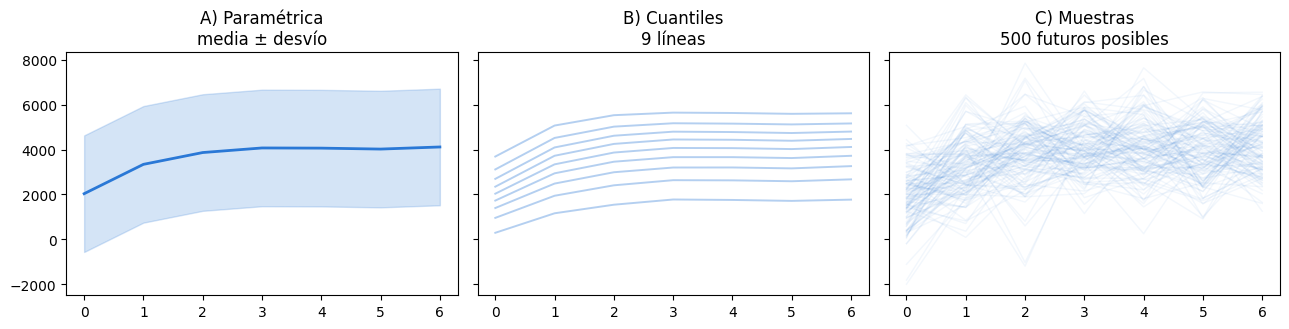

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.4), sharey=True)

ax[0].plot(centro, color="#2a78d6", lw=2)
ax[0].fill_between(range(H), centro - 2*sigma, centro + 2*sigma, color="#2a78d6", alpha=.2)
ax[0].set_title("A) Paramétrica\nmedia ± desvío")

for i, q in enumerate(QL):
    ax[1].plot(por_cuantiles[:, i], color="#2a78d6", alpha=.35, lw=1.4)
ax[1].set_title("B) Cuantiles\n9 líneas")

ax[2].plot(por_muestras[:120].T, color="#2a78d6", alpha=.06, lw=1)
ax[2].set_title("C) Muestras\n500 futuros posibles")
plt.tight_layout();

Las tres describen lo mismo. Se diferencian en qué preguntas te dejan responder:

- **A** es la más barata, pero si la realidad no tiene esa forma, no te lo puede decir.
- **B** no asume forma, pero solo sabemos los niveles que pedimos.
- **C** es la más flexible y la única que te deja **sumar días** para una decisión
  sobre el total del mes